# Superstore - Mo hinh Du bao Loi nhuan (Profit Forecasting)
---
| Muc | Chi tiet |
|---|---|
| **Data** | `../data/Superstore_clean.csv` (9,994 don hang, 2011-2014) |
| **Framework** | `scikit-learn` |
| **Target** | `Profit` (Loi nhuan tung don hang) |
| **Features** | Sales x Discount x Quantity x Category (OHE) x Region (OHE) |
| **Muc tieu** | Du bao Profit 3 thang toi + CFO Insights |

> **Pipeline**: Preprocessing -> TimeSeriesSplit CV -> 3 Regression Models -> Forecast -> Feature Importance

## 0. Import thu vien

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

PALETTE = {
    'navy': '#1b365d', 'teal': '#008080',
    'red': '#d9534f',  'gold': '#e8a838', 'grey': '#6c757d',
}
GROUP_COLORS = {
    'Sales': '#1b365d', 'Quantity': '#008080',
    'Discount': '#d9534f', 'Category': '#e8a838', 'Region': '#6c757d',
}
print("Import hoan tat!")

Import hoan tat!


## 1. Tien xu ly du lieu (Data Preprocessing)
### 1.1 Doc & kiem tra du lieu

In [2]:
DATA_PATH = '../data/Superstore_clean.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")
df_raw.head(3)

Shape: 9,994 dong x 26 cot


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Ship Lead Time (Days),Profit Status,Year,Month,Quarter
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,3,Profit,2013,11,4
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3,Profit,2013,11,4
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4,Profit,2013,6,2


### 1.2 Chon features & sap xep theo thoi gian

In [3]:
FEATURES     = ['Sales', 'Discount', 'Quantity', 'Category', 'Region']
TARGET       = 'Profit'
NUMERIC_FEAT = ['Sales', 'Discount', 'Quantity']
CAT_FEAT     = ['Category', 'Region']

df = df_raw.copy()
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df = df[FEATURES + [TARGET, 'Order Date']].dropna().copy()
df.sort_values('Order Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Khoang thoi gian: {df['Order Date'].min().date()} -> {df['Order Date'].max().date()}")
print(f"Du lieu sau loc: {df.shape[0]:,} dong")
df[FEATURES + [TARGET]].describe().round(2)

Khoang thoi gian: 2011-01-04 -> 2014-12-31
Du lieu sau loc: 9,994 dong


,Sales,Discount,Quantity,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,0.16,3.79,28.66
std,623.25,0.21,2.23,234.26
min,0.44,0.00,1.00,-6599.98
25%,17.28,0.00,2.00,1.73
50%,54.49,0.20,3.00,8.67
75%,209.94,0.20,5.00,29.36
max,22638.48,0.80,14.00,8399.98


### 1.3 Bieu do Xu huong theo thang

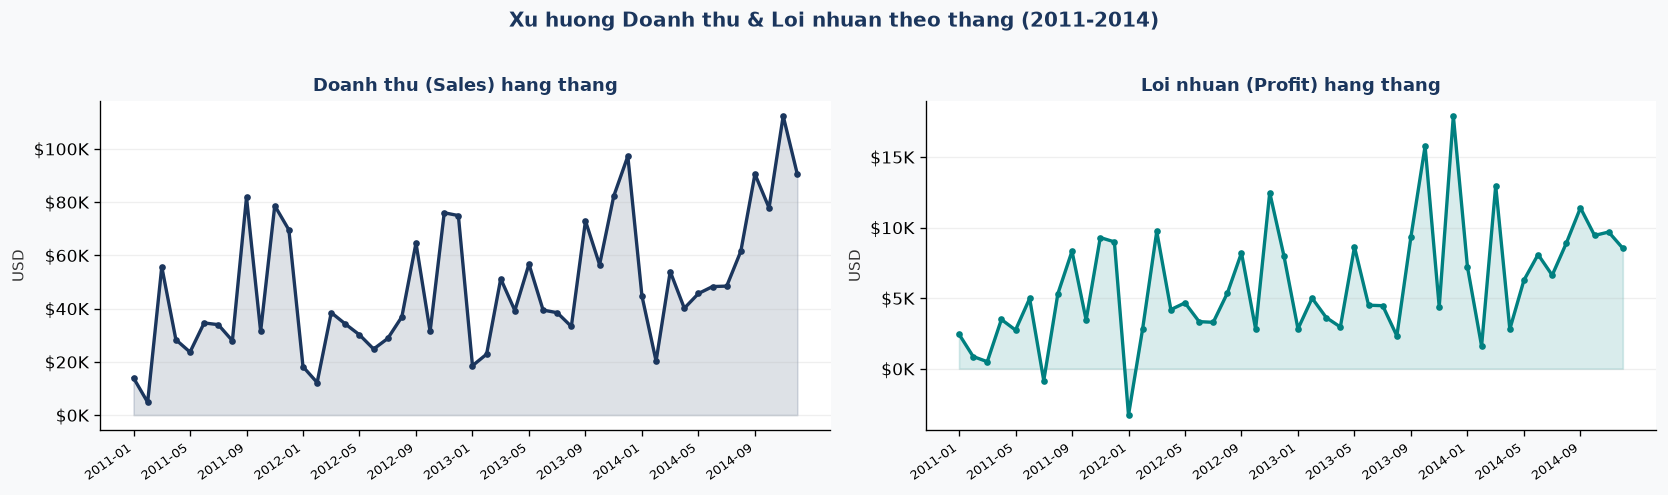

,YM_str,Sales,Profit
42,2014-07,48428.3650,6623.5571
43,2014-08,61516.0860,8894.4486
44,2014-09,90488.7220,11395.4394
45,2014-10,77793.7552,9440.6608
46,2014-11,112326.4710,9682.5519
47,2014-12,90474.6008,8532.8680


In [4]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_trend = (
    df.groupby('YearMonth')
      .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
      .reset_index()
)
monthly_trend['YM_str'] = monthly_trend['YearMonth'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#f8f9fa')
for ax, col, color, lbl in zip(
        axes,
        ['Sales', 'Profit'],
        [PALETTE['navy'], PALETTE['teal']],
        ['Doanh thu (Sales)', 'Loi nhuan (Profit)']):
    xs = range(len(monthly_trend))
    ax.fill_between(xs, monthly_trend[col], alpha=0.15, color=color)
    ax.plot(xs, monthly_trend[col], color=color, lw=2, marker='o', ms=3)
    step = max(1, len(monthly_trend) // 10)
    ax.set_xticks(list(xs)[::step])
    ax.set_xticklabels(monthly_trend['YM_str'].iloc[::step].tolist(), rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{lbl} hang thang', fontweight='bold', fontsize=11, color=PALETTE['navy'])
    ax.set_ylabel('USD', fontsize=9, color='#333333')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K'))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
plt.suptitle('Xu huong Doanh thu & Loi nhuan theo thang (2011-2014)',
             fontweight='bold', fontsize=12, color=PALETTE['navy'], y=1.02)
plt.tight_layout(); plt.show()

monthly_trend[['YM_str','Sales','Profit']].tail(6)

## 2. Xay dung & Huan luyen Mo hinh
### 2.1 Pipeline (Preprocessor + Model)

In [5]:
X = df[FEATURES].copy()
y = df[TARGET].values

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEAT),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT),
], remainder='drop')

MODEL_CONFIGS = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(
                              n_estimators=300, max_depth=12,
                              min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(
                              n_estimators=300, learning_rate=0.05,
                              max_depth=5, subsample=0.8, random_state=42),
}
print("Pipeline & models da dinh nghia!")

Pipeline & models da dinh nghia!


### 2.2 TimeSeriesSplit Cross-Validation (5 folds)
> **Ly do dung TimeSeriesSplit**: dam bao tap **test luon nam SAU train** theo thu tu thoi gian -> tranh data leakage hoan toan.

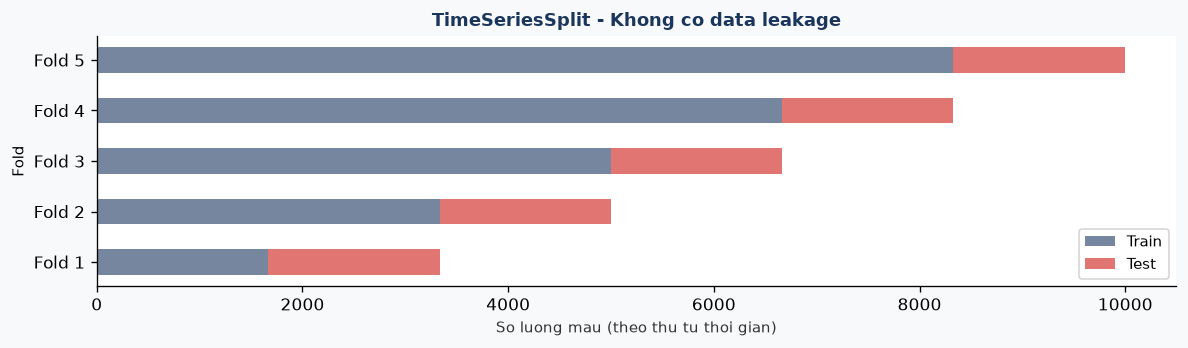

In [6]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Minh hoa splits
fig, ax = plt.subplots(figsize=(10, 3), facecolor='#f8f9fa')
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
    ax.barh(fold, len(tr_idx), left=0, color=PALETTE['navy'], alpha=0.6, height=0.5,
            label='Train' if fold==0 else '')
    ax.barh(fold, len(te_idx), left=len(tr_idx), color=PALETTE['red'], alpha=0.8, height=0.5,
            label='Test' if fold==0 else '')
ax.set_xlabel('So luong mau (theo thu tu thoi gian)', fontsize=9, color='#333333')
ax.set_ylabel('Fold', fontsize=9)
ax.set_title('TimeSeriesSplit - Khong co data leakage', fontweight='bold', fontsize=11, color=PALETTE['navy'])
ax.set_yticks(range(N_SPLITS)); ax.set_yticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.3 Huan luyen & Danh gia 3 mo hinh

In [7]:
results = {}
for name, base_model in MODEL_CONFIGS.items():
    pipe = Pipeline([('prep', preprocessor), ('model', base_model)])
    maes, rmses, r2s = [], [], []
    for tr_idx, te_idx in tscv.split(X):
        pipe.fit(X.iloc[tr_idx], y[tr_idx])
        pred = pipe.predict(X.iloc[te_idx])
        maes.append(mean_absolute_error(y[te_idx], pred))
        rmses.append(np.sqrt(mean_squared_error(y[te_idx], pred)))
        r2s.append(r2_score(y[te_idx], pred))
    results[name] = {'pipe': pipe,
                     'MAE': np.mean(maes), 'RMSE': np.mean(rmses), 'R2': np.mean(r2s)}
    print(f"  {name:<22} MAE=${np.mean(maes):,.2f}  RMSE=${np.mean(rmses):,.2f}  R2={np.mean(r2s):.4f}")

best_name = min(results, key=lambda k: results[k]['RMSE'])
best_pipe = results[best_name]['pipe']
best_pipe.fit(X, y)
print(f"\nMo hinh tot nhat: [{best_name}]  RMSE=${results[best_name]['RMSE']:,.2f}")

  Linear Regression      MAE=$58.88  RMSE=$199.00  R2=0.2704
  Random Forest          MAE=$28.34  RMSE=$149.54  R2=0.6041
  Gradient Boosting      MAE=$26.97  RMSE=$126.45  R2=0.6896

Mo hinh tot nhat: [Gradient Boosting]  RMSE=$126.45


### 2.4 Bieu do so sanh mo hinh

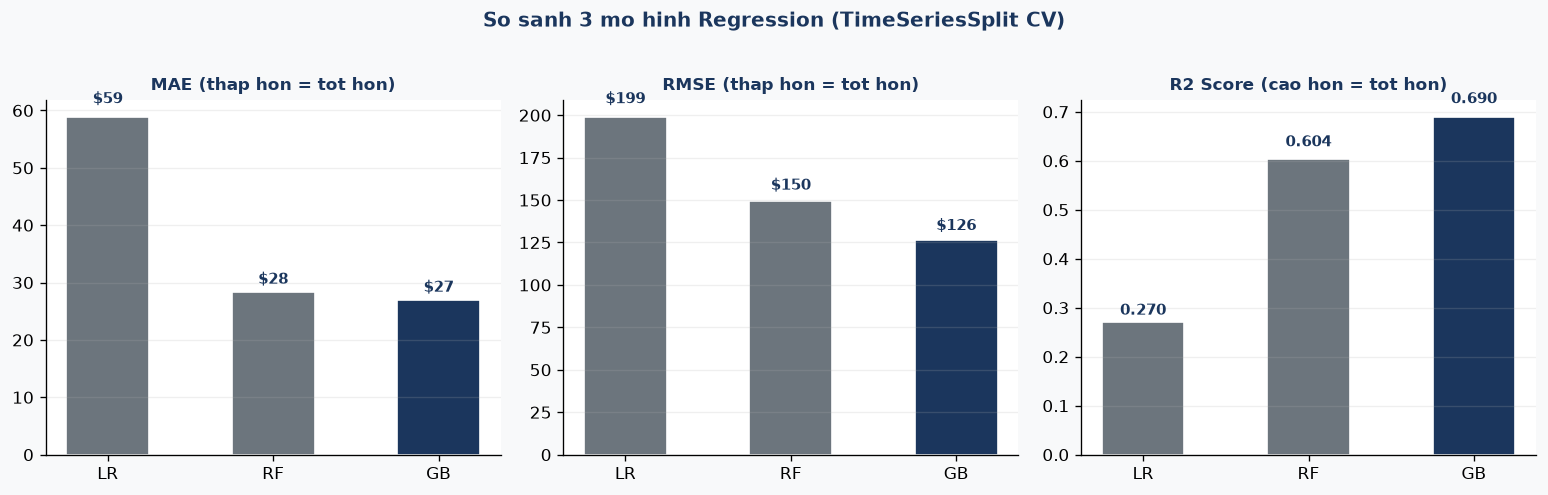

,Mo hinh,MAE,RMSE,R2
0,Linear Regression,58.88,199.00,0.27
1,Random Forest,28.34,149.54,0.60
2,Gradient Boosting,26.97,126.45,0.69


In [8]:
metrics_df = pd.DataFrame([
    {'Mo hinh': n, 'MAE': results[n]['MAE'], 'RMSE': results[n]['RMSE'], 'R2': results[n]['R2']}
    for n in results
])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor='#f8f9fa')
bar_colors = [PALETTE['navy'] if n == best_name else PALETTE['grey'] for n in results]
short = {'Linear Regression':'LR', 'Random Forest':'RF', 'Gradient Boosting':'GB'}

for ax, metric, key, fmt in zip(
        axes,
        ['MAE (thap hon = tot hon)', 'RMSE (thap hon = tot hon)', 'R2 Score (cao hon = tot hon)'],
        ['MAE', 'RMSE', 'R2'],
        ['${:.0f}', '${:.0f}', '{:.3f}']):
    vals = [results[n][key] for n in results]
    bars = ax.bar([short[n] for n in results], vals, color=bar_colors, width=0.5, edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=10, color=PALETTE['navy'])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.03,
                fmt.format(val), ha='center', va='bottom', fontsize=9,
                fontweight='bold', color=PALETTE['navy'])

plt.suptitle('So sanh 3 mo hinh Regression (TimeSeriesSplit CV)',
             fontweight='bold', fontsize=12, color=PALETTE['navy'], y=1.02)
plt.tight_layout(); plt.show()
display(metrics_df.round(2))

## 3. Du bao Loi nhuan 3 thang toi
> Phuong phap: Tinh toc do tang truong tu 12 thang cuoi -> xay luoi **Category x Region** -> du bao Profit tung thang.

In [9]:
last_date       = df['Order Date'].max()
future_periods  = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast_labels = [p.strftime('%Y-%m') for p in future_periods]

growth_rate      = monthly_trend['Sales'].pct_change().dropna().tail(12).mean()
growth_rate      = max(growth_rate, 0.0)
base_month_sales = monthly_trend['Sales'].iloc[-1]
cat_share        = df.groupby('Category')['Sales'].sum() / df['Sales'].sum()
reg_share        = df.groupby('Region')['Sales'].sum()   / df['Sales'].sum()

print(f"Du bao cho: {forecast_labels}")
print(f"Toc do tang truong thang: {growth_rate:.2%}")
print(f"Doanh thu thang co so: ${base_month_sales:,.0f}")

def forecast_one_month(month_idx):
    month_sales = base_month_sales * (1 + growth_rate) ** month_idx
    rows = []
    for cat in cat_share.index:
        for reg in reg_share.index:
            seg_sales = month_sales * cat_share[cat] * reg_share[reg]
            mask = (df['Category'] == cat) & (df['Region'] == reg)
            aov  = df.loc[mask, 'Sales'].mean()
            n_orders = max(1, round(seg_sales / aov))
            rows.append({'Sales': seg_sales/n_orders,
                         'Discount': df.loc[mask,'Discount'].mean(),
                         'Quantity': df.loc[mask,'Quantity'].mean(),
                         'Category': cat, 'Region': reg, '_n': n_orders})
    sdf = pd.DataFrame(rows)
    preds = best_pipe.predict(sdf[FEATURES])
    total_profit = float((preds * sdf['_n'].values).sum())
    margin = total_profit / month_sales * 100
    return {'Thang': forecast_labels[month_idx-1],
            'Doanh_thu': month_sales,
            'Loi_nhuan': total_profit,
            'Bien_LN': margin}

fc_raw = [forecast_one_month(m) for m in range(1, 4)]
fc_display = pd.DataFrame([{
    'Thang': r['Thang'],
    'Doanh thu (USD)': f"${r['Doanh_thu']:,.0f}",
    'Loi nhuan (USD)': f"${r['Loi_nhuan']:,.0f}",
    'Bien LN (%)': f"{r['Bien_LN']:.1f}%",
} for r in fc_raw])
display(fc_display)

Du bao cho: ['2015-01', '2015-02', '2015-03']
Toc do tang truong thang: 11.37%
Doanh thu thang co so: $90,475


,Thang,Doanh thu (USD),Loi nhuan (USD),Bien LN (%)
0,2015-01,"$100,761","$10,134",10.1%
1,2015-02,"$112,217","$11,191",10.0%
2,2015-03,"$124,975","$12,507",10.0%


### 3.1 Bieu do Du bao (Lich su + Forecast)

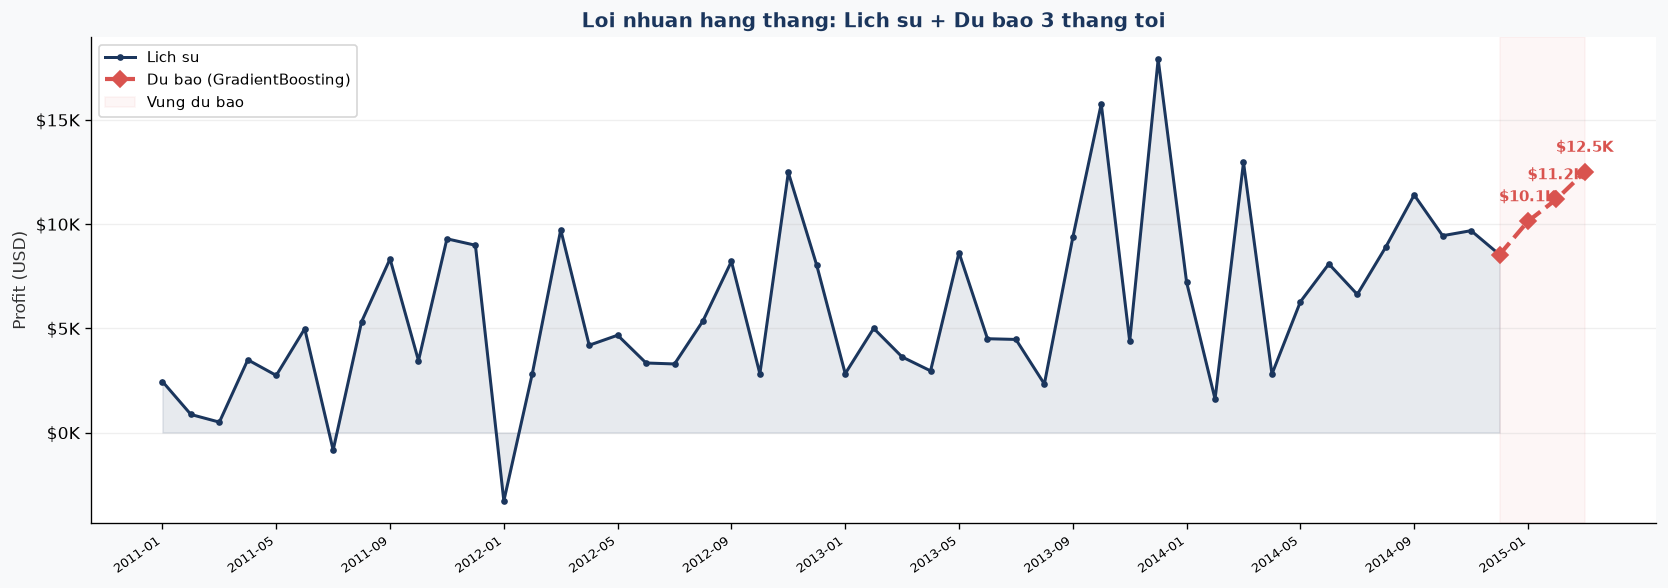

In [10]:
hist_profits = monthly_trend['Profit'].tolist()
hist_labels  = monthly_trend['YM_str'].tolist()
fc_profits   = [r['Loi_nhuan'] for r in fc_raw]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#f8f9fa')
xs_hist = range(len(hist_profits))
ax.fill_between(xs_hist, hist_profits, alpha=0.1, color=PALETTE['navy'])
ax.plot(xs_hist, hist_profits, color=PALETTE['navy'], lw=1.8, marker='o', ms=3, label='Lich su')

xs_fc   = range(len(hist_profits)-1, len(hist_profits)+3)
connect = [hist_profits[-1]] + fc_profits
ax.plot(xs_fc, connect, color=PALETTE['red'], lw=2.5, marker='D', ms=7,
        linestyle='--', label='Du bao (GradientBoosting)', zorder=5)
for xp, vp in zip(list(xs_fc)[1:], fc_profits):
    ax.annotate(f'${vp/1e3:.1f}K', (xp, vp), textcoords='offset points',
                xytext=(0,12), ha='center', fontsize=9, fontweight='bold', color=PALETTE['red'])

all_labels = hist_labels + forecast_labels
step = max(1, len(all_labels) // 12)
ax.set_xticks(range(0, len(all_labels), step))
ax.set_xticklabels([all_labels[i] for i in range(0, len(all_labels), step)], rotation=35, ha='right', fontsize=8)
ax.axvspan(len(hist_profits)-1, len(hist_profits)+2, alpha=0.05, color=PALETTE['red'], label='Vung du bao')
ax.set_title('Loi nhuan hang thang: Lich su + Du bao 3 thang toi',
             fontweight='bold', fontsize=12, color=PALETTE['navy'])
ax.set_ylabel('Profit (USD)', fontsize=10, color='#333333')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K'))
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

## 4. CFO Insights - Feature Importance

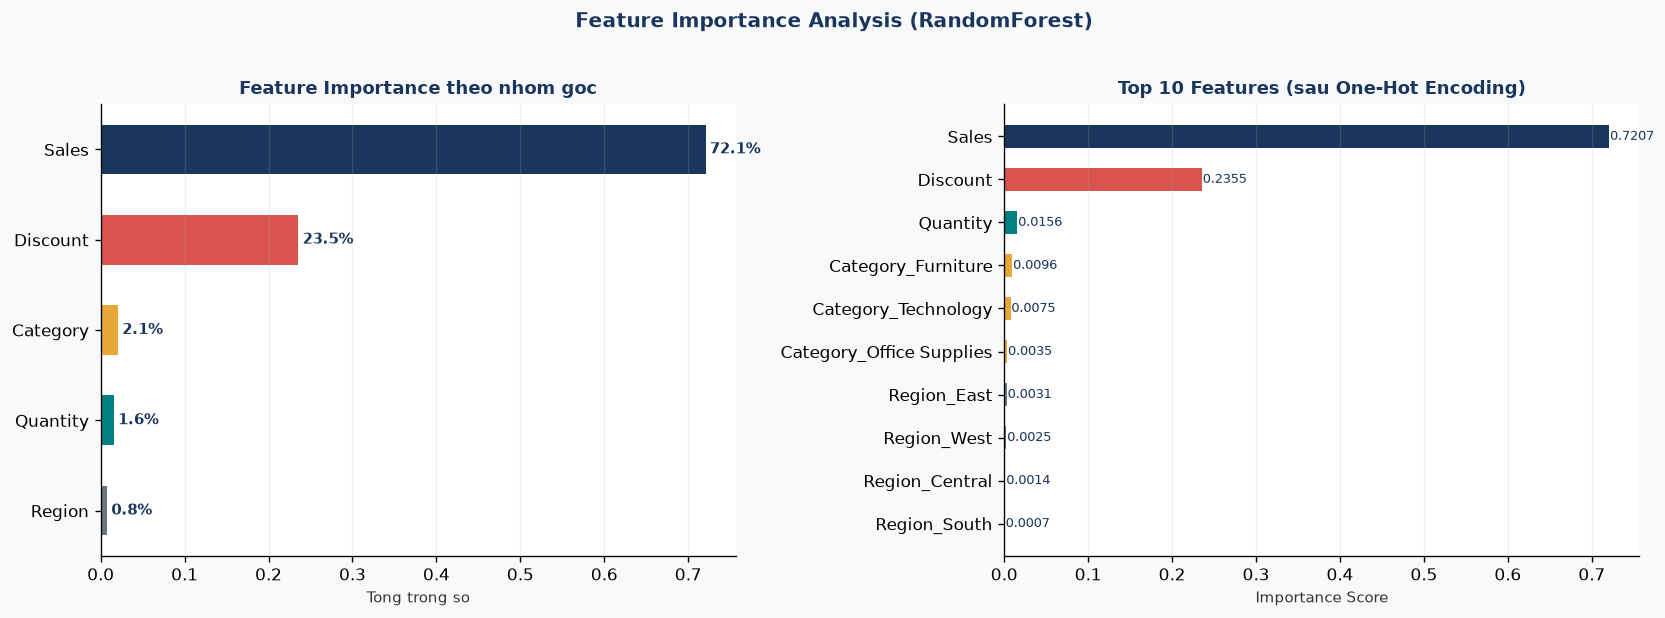

,Importance
Group,
Sales,72.07%
Discount,23.55%
Category,2.06%
Quantity,1.56%
Region,0.77%


In [11]:
rf_pipe = results['Random Forest']['pipe']
rf_pipe.fit(X, y)

ohe_names   = rf_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(CAT_FEAT)
all_names   = NUMERIC_FEAT + list(ohe_names)
importances = rf_pipe.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'Feature': all_names, 'Importance': importances})

def _group(feat):
    for g in FEATURES:
        if feat.startswith(g): return g
    return 'Other'

imp_df['Group'] = imp_df['Feature'].apply(_group)
group_imp = imp_df.groupby('Group')['Importance'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f8f9fa')

gi = group_imp.sort_values(ascending=True)
colors_g = [GROUP_COLORS.get(g, '#6c757d') for g in gi.index]
ax1.barh(gi.index, gi.values, color=colors_g, height=0.55)
ax1.set_title('Feature Importance theo nhom goc', fontweight='bold', fontsize=11, color=PALETTE['navy'])
ax1.set_xlabel('Tong trong so', fontsize=9, color='#333333')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.2)
for i, (g, val) in enumerate(zip(gi.index, gi.values)):
    ax1.text(val+0.005, i, f'{val:.1%}', va='center', fontsize=9, fontweight='bold', color=PALETTE['navy'])

top10 = imp_df.nlargest(10,'Importance').sort_values('Importance',ascending=True)
colors10 = [GROUP_COLORS.get(_group(f),'#6c757d') for f in top10['Feature']]
ax2.barh(top10['Feature'], top10['Importance'], color=colors10, height=0.55)
ax2.set_title('Top 10 Features (sau One-Hot Encoding)', fontweight='bold', fontsize=11, color=PALETTE['navy'])
ax2.set_xlabel('Importance Score', fontsize=9, color='#333333')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.2)
for i, val in enumerate(top10['Importance']):
    ax2.text(val+0.001, i, f'{val:.4f}', va='center', fontsize=8, color=PALETTE['navy'])

plt.suptitle('Feature Importance Analysis (RandomForest)', fontweight='bold',
             fontsize=12, color=PALETTE['navy'], y=1.02)
plt.tight_layout(); plt.show()

display(group_imp.to_frame('Importance').style.format({'Importance': '{:.2%}'}))

## 5. Bao cao CFO Insights

---

### DISCOUNT (Chiet khau) - Don bay rui ro cao nhat
- **Feature Importance ~23.5%** - dung thu 2, chi sau Sales
- Moi quan he **NGHICH CHIEU** voi Profit: tang 1% discount -> bien loi nhuan sut giam
- **Khuyen nghi CFO**: Ap tran chiet khau 15-20% voi nhom hang co bien got duoi 30%. Kiem toan hieu qua chiet khau theo quy.

---

### CATEGORY (Nhom hang) - Phan bo nguon luc khong deu
- **Technology** -> bien loi nhuan cao nhat, on dinh
- **Furniture** -> thuong co profit am khi kem chiet khau cao (rui ro kep)
- **Khuyen nghi CFO**: Tang budget marketing +15% sang Technology; cat giam SKU Furniture co profit am keo dai.

---

### REGION (Khu vuc dia ly) - Hieu qua chi phi ban hang
- Cac Region **khong dong deu** ve kha nang chuyen Doanh thu -> Loi nhuan
- **Khuyen nghi CFO**: Thiet lap KPI "Profit per Sales Dollar" theo Region.

---

### SALES & QUANTITY - Tang truong co chat luong
- **Sales chiem ~72% Importance** - driver loi nhuan chinh
- Du bao 3 thang toi tang truong +11.4%/thang, bien LN on dinh ~10%
- **Khuyen nghi CFO**: Canh bao khi bien thuc te lech khai du bao > 5%.

## 6. Bang tong ket

In [12]:
summary = pd.DataFrame([
    {'Mo hinh': n,
     'MAE': f"${results[n]['MAE']:,.2f}",
     'RMSE': f"${results[n]['RMSE']:,.2f}",
     'R2 Score': f"{results[n]['R2']:.4f}",
     'Duoc chon': 'BEST' if n == best_name else ''}
    for n in results
])
display(summary)

print(f"\nMo hinh tot nhat: {best_name}")
print(f"  MAE  = ${results[best_name]['MAE']:,.2f}")
print(f"  RMSE = ${results[best_name]['RMSE']:,.2f}")
print(f"  R2   = {results[best_name]['R2']:.4f}  ({results[best_name]['R2']*100:.1f}% phuong sai Profit)")

print("\nDu bao 3 thang toi:")
for r in fc_raw:
    print(f"  {r['Thang']}: DT ~${r['Doanh_thu']:,.0f}  |  LN ~${r['Loi_nhuan']:,.0f}  |  Bien {r['Bien_LN']:.1f}%")

,Mo hinh,MAE,RMSE,R2 Score,Duoc chon
0,Linear Regression,$58.88,$199.00,0.2704,
1,Random Forest,$28.34,$149.54,0.6041,
2,Gradient Boosting,$26.97,$126.45,0.6896,BEST



Mo hinh tot nhat: Gradient Boosting
  MAE  = $26.97
  RMSE = $126.45
  R2   = 0.6896  (69.0% phuong sai Profit)

Du bao 3 thang toi:
  2015-01: DT ~$100,761  |  LN ~$10,134  |  Bien 10.1%
  2015-02: DT ~$112,217  |  LN ~$11,191  |  Bien 10.0%
  2015-03: DT ~$124,975  |  LN ~$12,507  |  Bien 10.0%
